In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

In [2]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder

In [3]:
SEED = 67

# Python random
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch
torch.manual_seed(SEED)

# GPU (if available)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [5]:
train_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(20),

    transforms.RandomResizedCrop(
        size=224,
        scale=(0.75, 1.0),
        ratio=(0.9, 1.1)
    ),

    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.30,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.7178, 0.5677, 0.5456],
        std=[0.2214, 0.2109, 0.2252]
    )
])
test_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.7178, 0.5677, 0.5456],
        std=[0.2214, 0.2109, 0.2252]
    )
])

In [121]:
from path import Path
TRAIN_DIR = Path("/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train")
TEST_DIR = Path("/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test")
train_data = ImageFolder(TRAIN_DIR, train_aug)
test_data = ImageFolder(TEST_DIR, test_aug)
class_names = train_data.classes
train_size = len(train_data)
test_size = len(test_data)
print(f"Size of Train Data: {train_size}")
print(f"Size of Test Data: {test_size}")

Size of Train Data: 9605
Size of Test Data: 1000


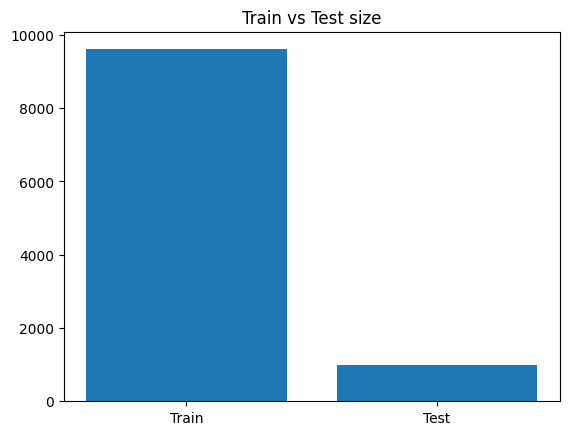

In [122]:
plt.bar(['Train', 'Test'], [train_size, test_size])
plt.title("Train vs Test size")
plt.savefig("dataset_size.png")

No of benign datapoints: 5000
No of malignant datapoints 4605


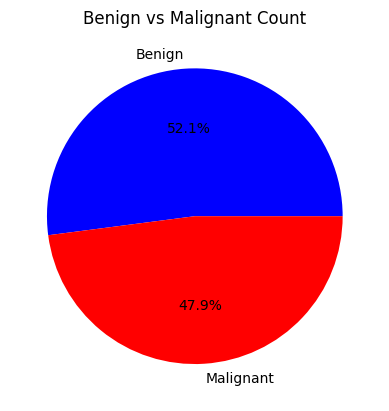

In [123]:
benign_path = Path(TRAIN_DIR+"/benign/")
benign_count = len(benign_path.files())
print(f"No of benign datapoints: {benign_count}")
print(f"No of malignant datapoints {len(train_data)- benign_count}")
plt.pie([benign_count, len(train_data)-benign_count], labels=['Benign', 'Malignant'], colors=['b', 'r'], autopct="%1.1f%%")
plt.title("Benign vs Malignant Count")
plt.savefig("patient-disease_count.png")

No of benign datapoints: 500
No of malignant datapoints 500


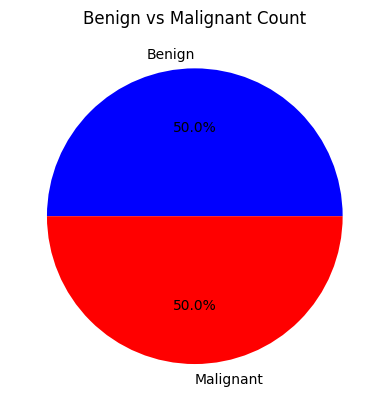

In [143]:
benign_path = Path(TEST_DIR+"/benign/")
benign_count = len(benign_path.files())
print(f"No of benign datapoints: {benign_count}")
print(f"No of malignant datapoints {len(test_data)- benign_count}")
plt.pie([benign_count, len(test_data)-benign_count], labels=['Benign', 'Malignant'], colors=['b', 'r'], autopct="%1.1f%%")
plt.title("Benign vs Malignant Count")
plt.savefig("patient-disease_count.png")

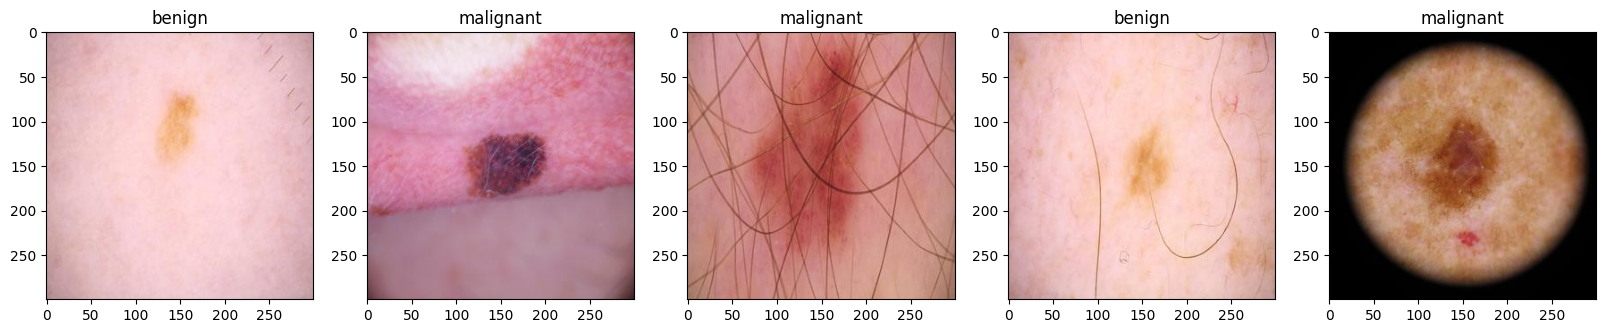

In [124]:
import re
img_paths = TRAIN_DIR.glob("*/*.jpg")
img_paths = random.choices(img_paths, k=5)
plt.figure(figsize=(20,20))
for i in range(0, 5):
    plt.subplot(1, 5,i+1)
    img_path = img_paths[i]
    class_name = re.sub(".+train/|/melanoma.*", "", img_path)
    plt.title(class_name)
    img = Image.open(img_path)
    plt.imshow(img)
    


In [125]:
import torch.multiprocessing as mp

try:
    mp.set_start_method("spawn", force=True)
except RuntimeError:
    pass

In [126]:
train_loader = DataLoader(train_data, 128, True,num_workers=0, pin_memory=True)
test_loader = DataLoader(test_data, 128, False, num_workers=0, pin_memory=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.242096..1.1506279].


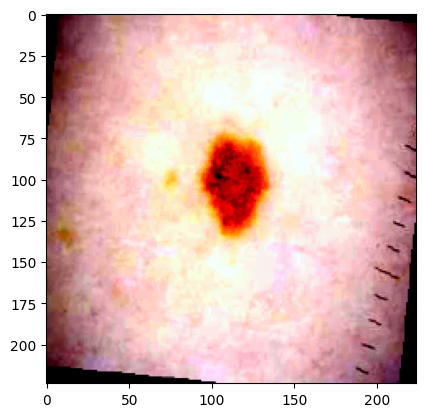

In [127]:
plt.imshow(train_data[0][0].permute(1,2,0))

In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
    def forward(self, x):
        return self.block(x)

In [7]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        self.features = nn.Sequential(ConvBlock(3, 32),
                                     ConvBlock(32, 64),
                                     ConvBlock(64, 128),
                                     ConvBlock(128, 256))
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(nn.Flatten(),
                                       nn.Linear(256, 128),
                                       nn.ReLU(),
                                       nn.Dropout(0.5),
                                       nn.Linear(128, num_classes))


    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x
        

In [9]:
from tqdm.auto import tqdm
from torchmetrics import Accuracy
from torch.amp import autocast, GradScaler
scaler = GradScaler("cuda", enabled=device== "cuda")
acc_fn = Accuracy(task="binary").to(device)
def train(model, loader, optimizer, loss_fn, device):
    train_loss = 0
    model.train()
    acc_fn.reset()
    for x, y in tqdm(loader, leave=False, desc='Training'):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True).unsqueeze(1).float()
        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda", enabled=device == "cuda"):
            logits = model(x)
            loss = loss_fn(logits, y)
        
        scaler.scale(loss).backward()
        
        scaler.step(optimizer)
        
        scaler.update()
        train_loss += loss.item()
        acc_fn.update(logits, y)
        
    return train_loss/len(loader), acc_fn.compute()

In [10]:
def evaluate(model, loader, loss_fn, device):
    test_loss = 0
    model.eval()
    acc_fn.reset()
    with torch.inference_mode():
        for x, y in tqdm(loader, leave=False, desc='Evaluating'):
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True).unsqueeze(1).float()
            with autocast("cuda", enabled=device == "cuda"):
                logits = model(x)
                test_loss += loss_fn(logits, y).item()
            acc_fn.update(logits, y)
    return test_loss/len(loader), acc_fn.compute()

In [132]:
model = CustomCNN()
model.to(device);
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

Using 2 GPUs!


In [133]:
EPOCHS = 50
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.01
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, EPOCHS)

In [ ]:
best_val_loss = float("inf")

patience = 10
counter = 0

train_history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[]}
for i in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, loss_fn, device)
    test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)
    scheduler.step()
    if test_loss < best_val_loss:
        best_val_loss = test_loss
        counter = 0
    
        torch.save(model.module.state_dict(), "best_model.pth")
        print(f"Best model saved on epoch: {i}")

    else:
        counter += 1
    if counter >= patience:
        print("Early stopping...")
        break
    train_history['train_loss'].append(train_loss)
    train_history['train_acc'].append(train_acc.item())
    train_history['test_loss'].append(test_loss)
    train_history['test_acc'].append(test_acc.item())
    print(f"Epoch: {i} | Train Loss: {train_loss:.3f} | Train Accuracy: {train_acc:.3f} | Test Loss: {test_loss:.3f} | Test Accuracy: {test_acc:.3f}")

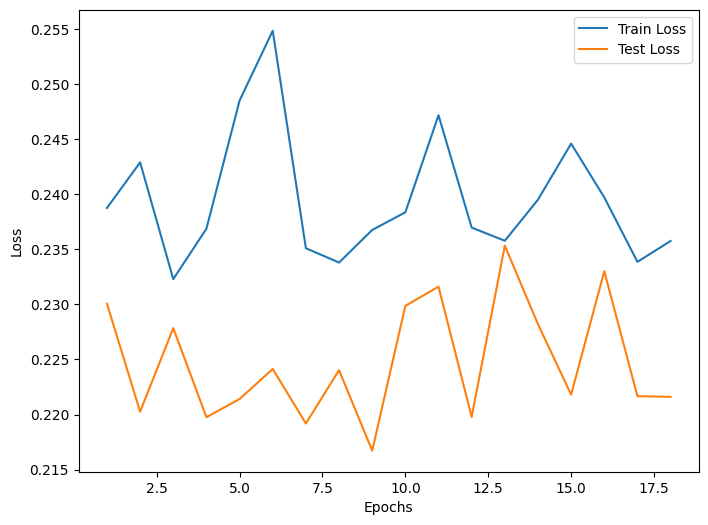

In [138]:
plt.figure(figsize=(8,6))
plt.plot(range(1, len(train_history['train_loss'])+1), train_history['train_loss'], label="Train Loss")
plt.plot(range(1, len(train_history['test_loss'])+1), train_history['test_loss'], label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("loss_plot.png")

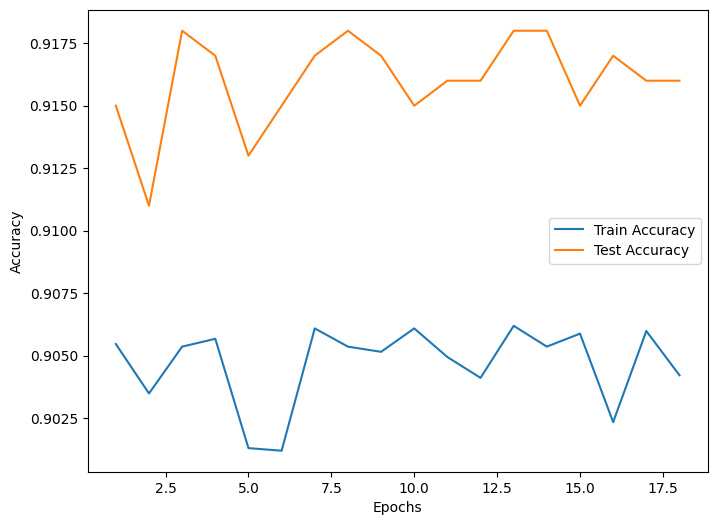

In [139]:
plt.figure(figsize=(8,6))
plt.plot(range(1, len(train_history['train_acc'])+1), train_history['train_acc'], label="Train Accuracy")
plt.plot(range(1, len(train_history['test_acc'])+1), train_history['test_acc'], label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("accuracy_plot.png")

In [11]:
saved_model = CustomCNN()
checkpoint = torch.load('best_model.pth', map_location='cpu') 
saved_model.load_state_dict(checkpoint)
saved_model.eval();

In [15]:
dummy_input = torch.randn(1, 3, 224, 224)

torch.onnx.export(
    saved_model,
    dummy_input,
    "model.onnx",
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"},
    }
)

/tmp/ipykernel_16722/685163579.py:3: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0807 10:52:36.638000 16722 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `CustomCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CustomCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/home/abdullah/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/abdullah/Documents/Projects/skin-cancer-detection/venv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdullah/Documents/Projects/skin-cancer-detection/venv/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in cal

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.13.0+cu130',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[batch_size,3,224,224]>
            ),
            outputs=(
                %"output"<FLOAT,[batch_size,1]>
            ),
            initializers=(
                %"features.0.block.0.weight"<FLOAT,[32,3,3,3]>{Tensor(...)},
                %"features.0.block.0.bias"<FLOAT,[32]>{Tensor(...)},
                %"features.1.block.0.bias"<FLOAT,[64]>{Tensor(...)},
                %"features.2.block.0.bias"<FLOAT,[128]>{Tensor(...)},
                %"features.3.block.0.bias"<FLOAT,[256]>{Tensor(...)},
                %"classifier.1.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"classifier.4.weight"<FLOAT,[1,128]>{TorchTensor(...)},
          

In [ ]:
from sklearn.metrics import f1_score, classification_report, recall_score, accuracy_score
y_true_list= []
y_preds_list = []
y_logits_list = []
thresholds = [0.3, 0.33, 0.4, 0.45, 0.5, 0.55, 0.6, 0.66, 0.7, 0.77]
for t in thresholds:
    acc = 0
    print('threshold:', t)
    with torch.inference_mode():
        for x, y in test_loader:
            logits = saved_model(x)
            probs = torch.sigmoid(logits)
            preds = (probs >= t).float()
    
            y_true_list.append(y.cpu().numpy())
            y_preds_list.append(preds.cpu().numpy())
            y_logits_list.append(logits.cpu().numpy())
            


    y_true = np.concatenate(y_true_list)
    y_preds = np.concatenate(y_preds_list)
    y_logits = np.concatenate(y_logits_list)
    recall = recall_score(y_true, y_preds)
    acc = accuracy_score(y_true, y_preds)
    print(f"Accuracy: {acc} | Recall: {recall} ")
    print(classification_report(y_true, y_preds))


threshold: 0.3
Accuracy: 0.904 | Recall: 0.892 
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       500
           1       0.91      0.89      0.90       500

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000

threshold: 0.33
Accuracy: 0.906 | Recall: 0.891 
              precision    recall  f1-score   support

           0       0.89      0.92      0.91      1000
           1       0.92      0.89      0.90      1000

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000

threshold: 0.4
Accuracy: 0.907 | Recall: 0.8866666666666667 
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1500
           1       0.92      0.89      0.91      1500

    accuracy            

In [ ]:
try:
    import pytorch_grad_cam
except Exception as e:
    !pip install grad-cam

In [161]:
model = CustomCNN()
checkpoint = torch.load('/kaggle/working/best_model.pth', map_location='cpu') 
model.load_state_dict(checkpoint)
model.to(device)
model.eval();

In [162]:
target_layers = [model.features[-1].block[0]]

In [163]:
print(model.features[-1].block[0])

Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [253]:
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.7178, 0.5677, 0.5456],
        std=[0.2214, 0.2109, 0.2252]
    )
])
image_path = input("Enter Image Path: ")
image = Image.open(image_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)

Enter Image Path:  /kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/malignant/melanoma_10137.jpg


In [254]:
with torch.inference_mode():
    output = model(input_tensor)

prob = torch.sigmoid(output)

prediction = int(prob > 0.4)

print("Probability:", prob.item())

print("Prediction:", prediction)

Probability: 0.07830274105072021
Prediction: 0


In [255]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[ClassifierOutputTarget(0)]
)

grayscale_cam = grayscale_cam[0]

In [256]:
import numpy as np
from pytorch_grad_cam.utils.image import show_cam_on_image

rgb_img = np.array(image.resize((224,224))) / 255.0

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

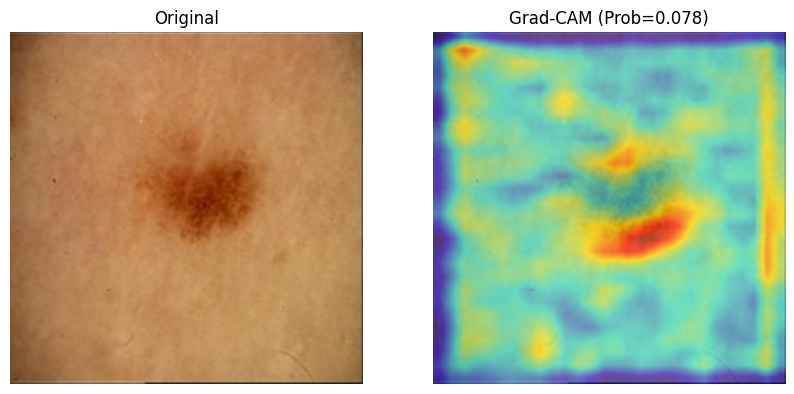

In [257]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title(f"Grad-CAM (Prob={prob.item():.3f})")
plt.axis("off")
plt.savefig("grad-cam_benign.png")
